<div style="background-color: lavender; padding: 20px; border-radius: 10px; font-size: 30px;">
    <b>Customer Churn Prediction - Data Science Project - Celebal Technologies</b><br>
    <b>By - Ananya Sharma</b>
</div>

<div style="background-color: #F0F8FF; padding: 10px; border-radius: 5px; font-size: 18px;">
<b>Importing Libraries</b>
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<div style="background-color: #F0F8FF; padding: 10px; border-radius: 5px; font-size: 18px;">
<b>Loading Dataset</b>
</div>

#### connected with kaggle API to download the dataset as zip file and then extracting

In [2]:
pip install kaggle

In [3]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile
with zipfile.ZipFile("telco-customer-churn.zip", 'r') as zip_ref:
    print(zip_ref.namelist())
    zip_ref.extractall("telco_data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
df = pd.read_csv("telco_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.shape

(7043, 21)

#### Column cutomerID is irrelevant and can be dropped for analysis. Also changing the data type of column 'TotalCharges' from object to float, and converting any irrelevant entry to 'NaN'.

In [8]:
df.drop('customerID', axis=1, inplace=True)

In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [11]:
df['TotalCharges'].isna().sum()

11

####  Found 11 blank entries were present in 'TotalCharges' which were changed to NaN dropping them now: 

In [12]:
df.dropna(inplace=True)

In [13]:
df['TotalCharges'].isna().sum()

0

#### Checking once other object type columns too, if same issue of blank spaces is present or not and found no more such entries.

In [14]:
for col in df.select_dtypes(include='object').columns:
    blank_count = df[col].isin([' ', '']).sum()
    if blank_count >= 0:
        print(f"Column '{col}' has {blank_count} blank entries.")

Column 'gender' has 0 blank entries.
Column 'Partner' has 0 blank entries.
Column 'Dependents' has 0 blank entries.
Column 'PhoneService' has 0 blank entries.
Column 'MultipleLines' has 0 blank entries.
Column 'InternetService' has 0 blank entries.
Column 'OnlineSecurity' has 0 blank entries.
Column 'OnlineBackup' has 0 blank entries.
Column 'DeviceProtection' has 0 blank entries.
Column 'TechSupport' has 0 blank entries.
Column 'StreamingTV' has 0 blank entries.
Column 'StreamingMovies' has 0 blank entries.
Column 'Contract' has 0 blank entries.
Column 'PaperlessBilling' has 0 blank entries.
Column 'PaymentMethod' has 0 blank entries.
Column 'Churn' has 0 blank entries.


<div style="background-color: #F0F8FF; padding: 10px; border-radius: 5px; font-size: 18px;">
<b>Exploratory Data Analysis</b>
</div>

### UNIVARIATE ANALYSIS

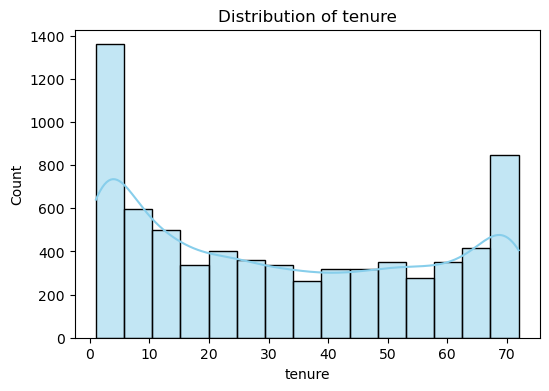

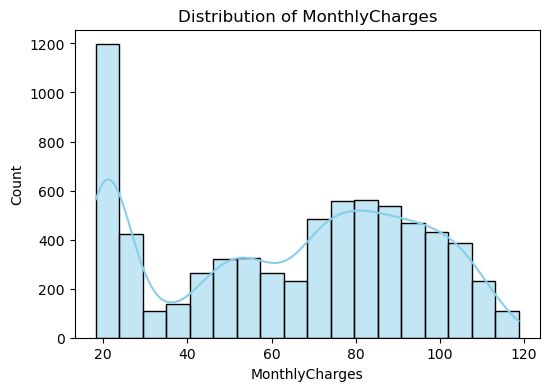

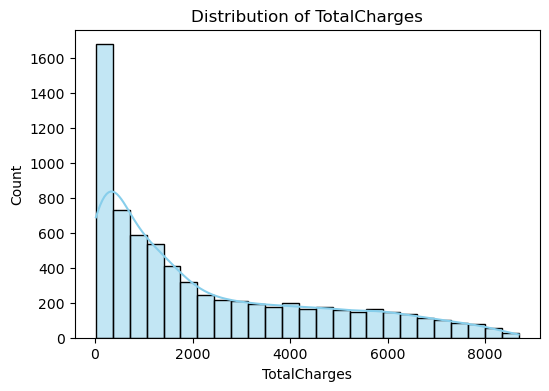

In [22]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

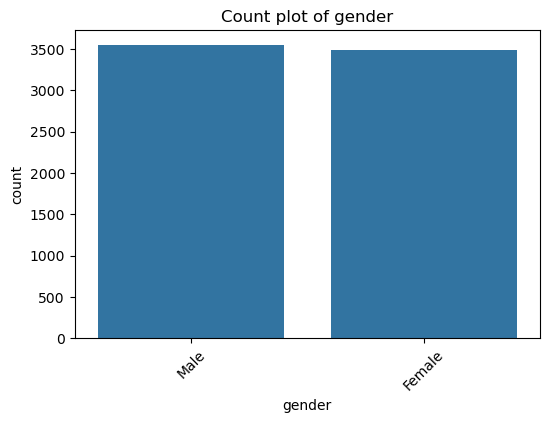

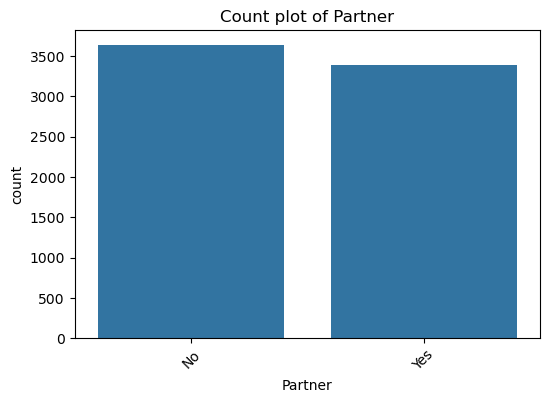

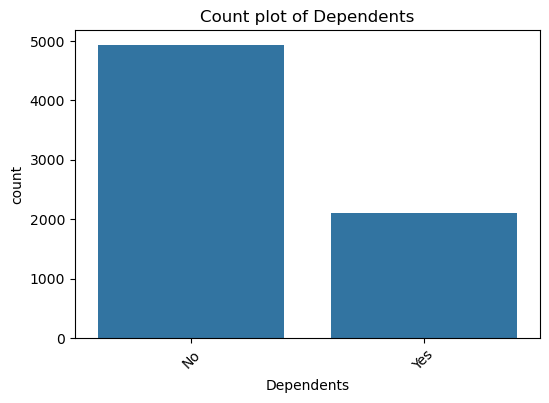

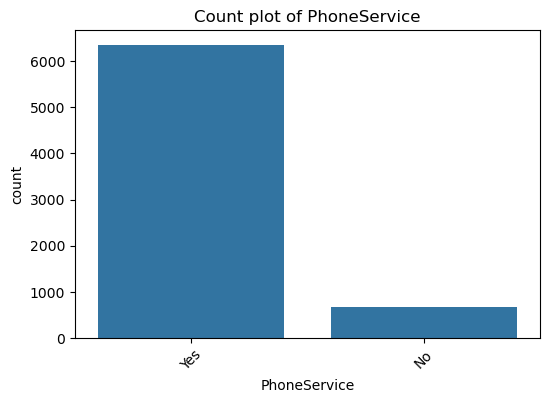

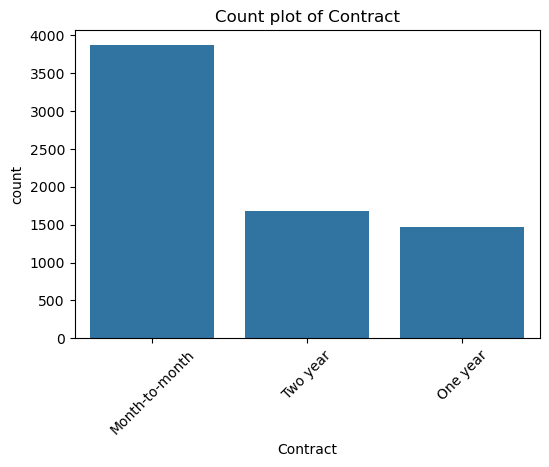

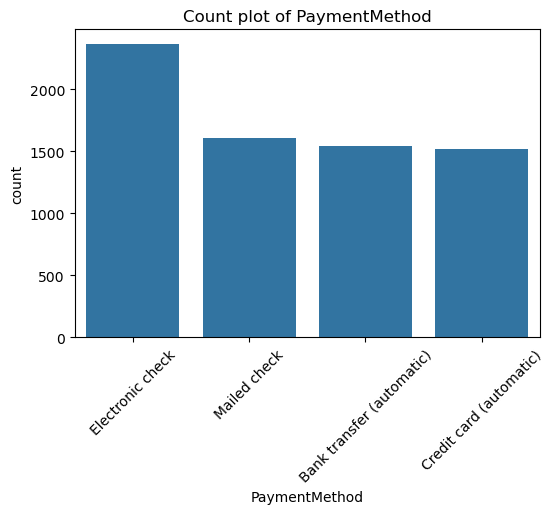

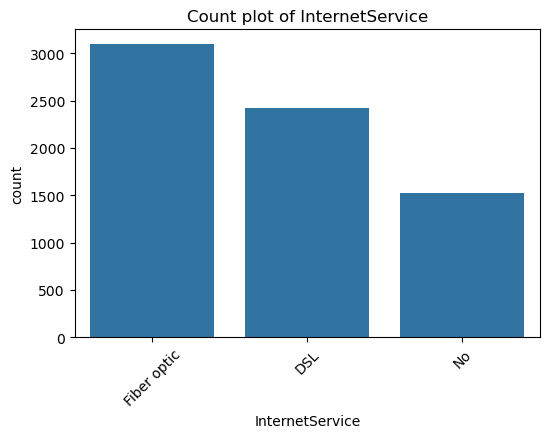

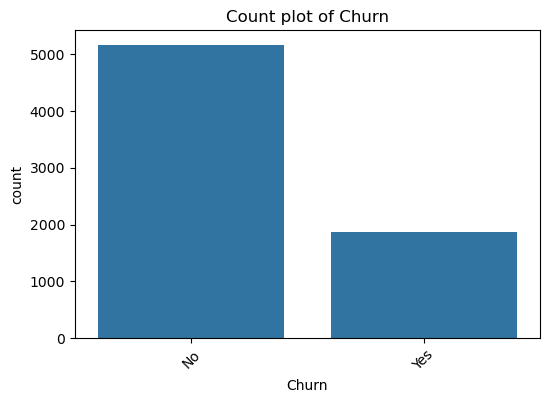

In [23]:
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'Contract', 
            'PaymentMethod', 'InternetService', 'Churn']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Count plot of {col}')
    plt.xticks(rotation=45)
    plt.show()

### BIVARIATE ANALYSIS

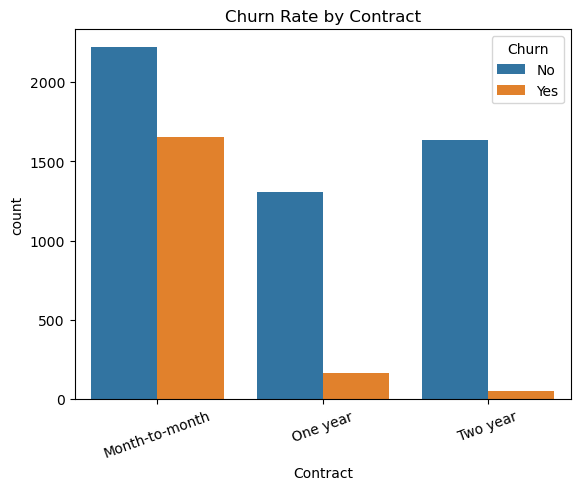

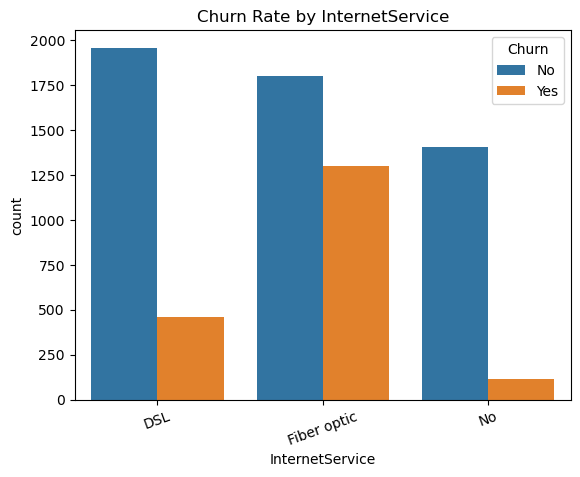

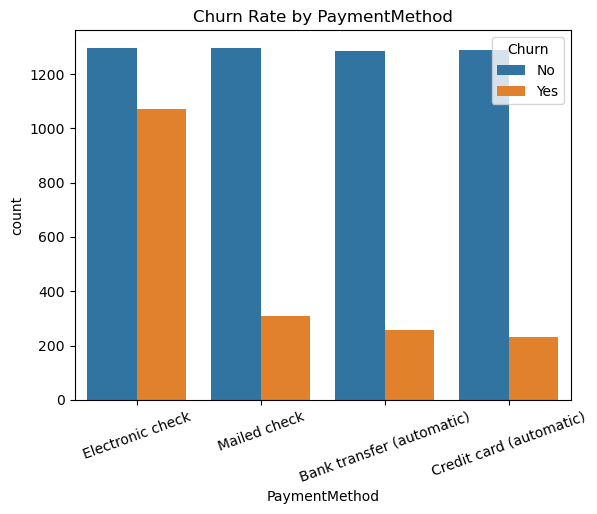

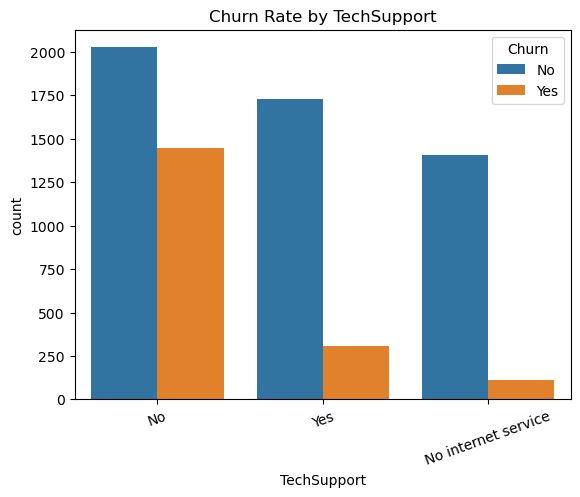

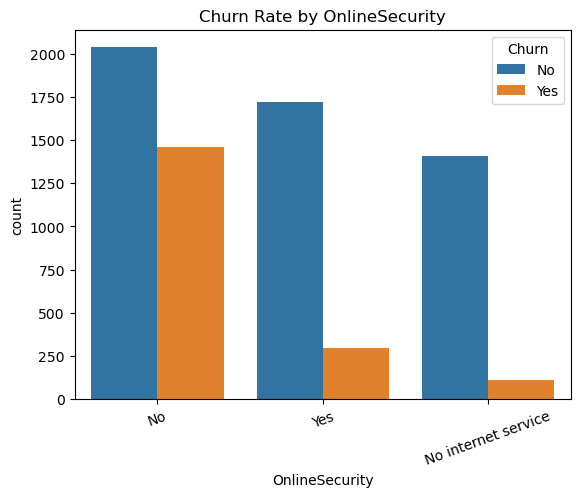

In [16]:
cols = ['Contract','InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']
for col in cols:
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'Churn Rate by {col}')
    plt.xticks(rotation=20)
    plt.show()

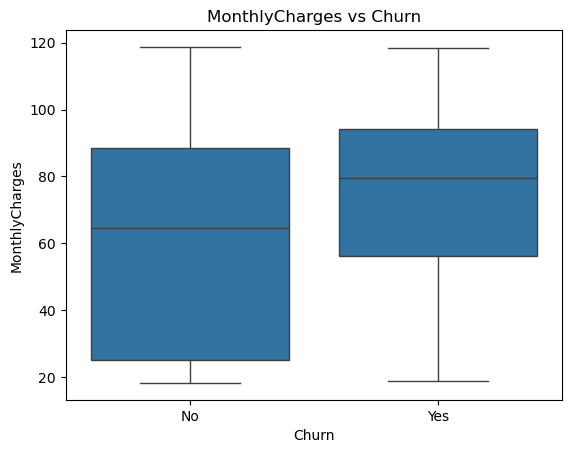

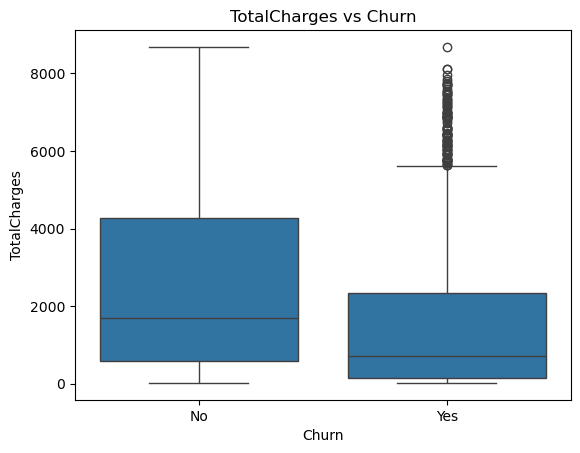

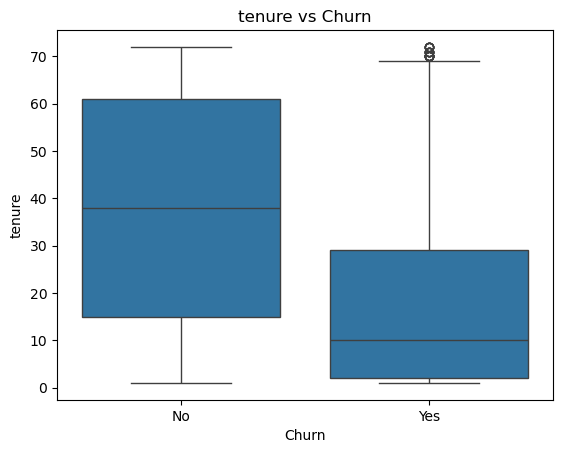

In [17]:
ncols=['MonthlyCharges','TotalCharges','tenure']
for col in ncols:
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
    plt.show()

In [30]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

#### The data is imbalanced Churn ='No' is much more than Churn='Yes'

<Axes: >

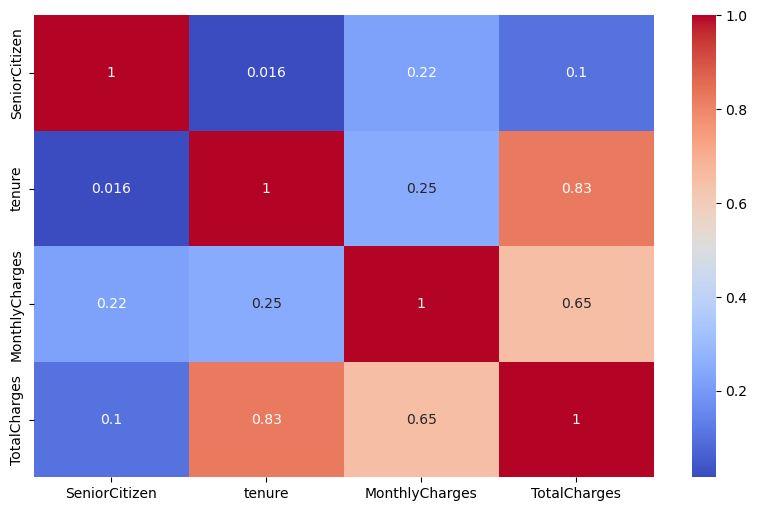

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

<div style="background-color: #F0F8FF; padding: 10px; border-radius: 5px; font-size: 18px;">
<b>Insights Derived</b>
</div>

<b>UNIVARIATE ANALYSIS INSIGHTS -</b> 

<b>Churn (Target Variable)</b>- 
1.There is an imbalance: Class ("No") dominates.
Thus, it would be important to address it via stratified split or class balancing methods (like SMOTE or class weights) during model training.

<b>TotalCharges</b>-
Continuous variable with a wide spread.
Some initial outliers were seen in boxplots (especially on "Churn = Yes" side), but IQR & Z-score later showed no outliers — likely due to: Distribution being skewed.
Outliers visible only in specific churn groups, not in the full dataset.
Right-skewed: Many customers have low charges, few with very high charges.

<b>Tenure</b> -
Right-skewed distribution.
Many customers are new/short-term users (low tenure).
Suggests high churn might be linked to newer customers.

<b>MonthlyCharges</b>-
More evenly spread.
Important to assess in context of service subscriptions.

<b>BIVARIATE ANALYSIS INSIGHTS -
    
<b>*TotalCharges vs Churn* -</b>
1. Customers who churned tend to have lower TotalCharges.
2. "Yes Churn" mostly has lower values with few outliers. Suggests customers leave early (lower charges = less tenure).
3. "No Churn" has higher median and a wide range.

<b>*Tenure vs Churn* -</b> 
1. Customers with shorter tenure are more likely to churn.
2. Long-term customers tend to stay loyal.

<b>*MonthlyCharges vs Churn* -</b>
1. High charges are linked with more churn, This suggests pricing issues or dissatisfaction with expensive plans.

<div style="background-color: #F0F8FF; padding: 10px; border-radius: 5px; font-size: 18px;">
<b>Checking for Outliers</b>
</div>

In [26]:
for col in ncols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"Outliers in {col}: {len(outliers)}")

Outliers in MonthlyCharges: 0
Outliers in TotalCharges: 0
Outliers in tenure: 0


There are no outliers present. Next Machine Learning and processing part will be covered